In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dataset-kiu/labels/test_subset2.csv
/kaggle/input/dataset-kiu/labels/train_subset1.csv
/kaggle/input/dataset-kiu/labels/test_subset4.csv
/kaggle/input/dataset-kiu/labels/train_subset4.csv
/kaggle/input/dataset-kiu/labels/train_subset3.csv
/kaggle/input/dataset-kiu/labels/val_subset2.csv
/kaggle/input/dataset-kiu/labels/train_subset2.csv
/kaggle/input/dataset-kiu/labels/test_subset1.csv
/kaggle/input/dataset-kiu/labels/val_subset0.csv
/kaggle/input/dataset-kiu/labels/val_subset4.csv
/kaggle/input/dataset-kiu/labels/test_subset3.csv
/kaggle/input/dataset-kiu/labels/test_subset0.csv
/kaggle/input/dataset-kiu/labels/train_subset0.csv
/kaggle/input/dataset-kiu/labels/val_subset3.csv
/kaggle/input/dataset-kiu/labels/val_subset1.csv
/kaggle/input/dataset-kiu/labels/labels.csv
/kaggle/input/dataset-kiu/images/20171219-112552-3.jpg
/kaggle/input/dataset-kiu/images/20180112-091948-2.jpg
/kaggle/input/dataset-kiu/images/20170217-145044-0.jpg
/kaggle/input/dataset-kiu/images/20170217

In [2]:
import cv2
import os
from tqdm import tqdm

# --- Configuration ---
SOURCE_DIR = '/kaggle/input/dataset-kiu/images'
TARGET_DIR = '/kaggle/working/clahe_processed_images/'

# Create the target directory if it doesn't exist
os.makedirs(TARGET_DIR, exist_ok=True)

# Get a list of all image files
image_files = [f for f in os.listdir(SOURCE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

print(f"Found {len(image_files)} images. Starting CLAHE preprocessing...")

# --- Processing Loop ---
for filename in tqdm(image_files):
    # Load the image
    image_path = os.path.join(SOURCE_DIR, filename)
    original_img = cv2.imread(image_path)
    
    if original_img is None:
        print(f"Warning: Could not read {filename}. Skipping.")
        continue

    # Apply CLAHE (same logic as your single-image script)
    lab_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab_img)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l_channel)
    merged_channels = cv2.merge([cl, a_channel, b_channel])
    contrast_corrected_img = cv2.cvtColor(merged_channels, cv2.COLOR_LAB2BGR)
    
    # Save the processed image to the new directory
    save_path = os.path.join(TARGET_DIR, filename)
    cv2.imwrite(save_path, contrast_corrected_img)

print("Preprocessing complete!")

Found 17509 images. Starting CLAHE preprocessing...


100%|██████████| 17509/17509 [05:07<00:00, 56.94it/s]

Preprocessing complete!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import timm
import copy
import os
import numpy as np
from tqdm import tqdm

# --- 1. DINO Components and Helper Classes (Unchanged) ---
class MultiCropTransform:
    def __init__(self, global_crops_scale, local_crops_scale, local_crops_number):
        self.global_transform = transforms.Compose([
            transforms.RandomResizedCrop(224, scale=global_crops_scale, interpolation=Image.BICUBIC),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
            transforms.RandomGrayscale(p=0.2),
            transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        self.local_transform = transforms.Compose([
            transforms.RandomResizedCrop(96, scale=local_crops_scale, interpolation=Image.BICUBIC),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
            transforms.RandomGrayscale(p=0.2),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        self.local_crops_number = local_crops_number
    def __call__(self, image):
        crops = [self.global_transform(image), self.global_transform(image)]
        for _ in range(self.local_crops_number):
            crops.append(self.local_transform(image))
        return crops

class UnlabeledImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = [
            os.path.join(root_dir, f) for f in os.listdir(root_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image_crops = self.transform(image)
        return image_crops, 0

class DINOLoss(nn.Module):
    def __init__(self, out_dim, teacher_temp=0.04, student_temp=0.1):
        super().__init__()
        self.student_temp = student_temp
        self.teacher_temp = teacher_temp
        self.center = nn.Parameter(torch.zeros(1, out_dim), requires_grad=False)
    def forward(self, student_output, teacher_output):
        student_out = student_output / self.student_temp
        teacher_out = F.softmax((teacher_output - self.center) / self.teacher_temp, dim=-1)
        loss = torch.sum(-teacher_out * F.log_softmax(student_out, dim=-1), dim=-1)
        return loss.mean()

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = np.inf
        self.stop_training = False
    def __call__(self, train_loss):
        if train_loss < self.best_loss - self.min_delta:
            self.best_loss = train_loss
            self.counter = 0
        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                print("Early stopping triggered!")
                self.stop_training = True

# --- 2. Main Training Script ---
if __name__ == '__main__':
    # --- Setup: Parameters and Device (MODIFIED) ---
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    EPOCHS = 110
    BATCH_SIZE = 16  # Reduced batch size
    ACCUMULATION_STEPS = 2 # This makes the effective batch size 16 * 2 = 32
    LEARNING_RATE = 0.01
    
    # --- Data Loading (MODIFIED) ---
    data_path = '/kaggle/working/clahe_processed_images/'
    
    if not os.path.isdir(data_path) or not os.listdir(data_path):
        print(f"Error: Directory '{data_path}' is empty or does not exist.")
    else:
        dino_transform = MultiCropTransform(
            global_crops_scale=(0.4, 1.0),
            local_crops_scale=(0.05, 0.4),
            local_crops_number=4  # Reduced local crops
        )
        dataset = UnlabeledImageDataset(root_dir=data_path, transform=dino_transform)
        data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
        print(f"Found {len(dataset)} images in '{data_path}'")
        
        # --- Model Setup ---
        student = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=0).to(device)
        teacher = copy.deepcopy(student)
        for p in teacher.parameters():
            p.requires_grad = False

        # --- Loss, Optimizer, and Scaler (MODIFIED) ---
        dino_loss = DINOLoss(
                   out_dim=student.embed_dim,
                             teacher_temp=0.07,  # Increased from the default 0.04
                              student_temp=0.1
                           ).to(device)
        optimizer = torch.optim.AdamW(student.parameters(), lr=LEARNING_RATE)
        scaler = torch.cuda.amp.GradScaler() # For Mixed Precision
        early_stopper = EarlyStopping(patience=10, min_delta=0.001)
        
        # --- The Training Loop (MODIFIED) ---
        print("Starting DINO Pre-training with optimizations...")
        for epoch in range(EPOCHS):
            total_loss = 0
            optimizer.zero_grad() # Zero gradients at the start of the epoch for accumulation
            
            for i, (images_list, _) in enumerate(tqdm(data_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")):
                images = [img.to(device) for img in images_list]
                global_crops = torch.cat(images[:2])
                
                # Use mixed precision
                with torch.cuda.amp.autocast():
                    teacher_output = teacher(global_crops)
                    student_output = student(global_crops)
                    loss = dino_loss(student_output, teacher_output.detach())
                
                # Scale the loss and backward pass
                scaler.scale(loss).backward()
                
                # Gradient Accumulation Step
                if (i + 1) % ACCUMULATION_STEPS == 0:
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
                
                with torch.no_grad():
                    for ps, pt in zip(student.parameters(), teacher.parameters()):
                        pt.data.mul_(0.996).add_((1 - 0.996) * ps.data)
                        
                total_loss += loss.item()
            
            avg_loss = total_loss / len(data_loader)
            print(f"Epoch {epoch+1}/{EPOCHS} - Average Loss: {avg_loss:.4f}")
            
            early_stopper(avg_loss)
            if early_stopper.stop_training:
                break
                
        print("Finished DINO Pre-training.")
        torch.save(student.state_dict(), '/kaggle/working/dino_pretrained_final.pth')
        print("Pre-trained student model weights saved to '/kaggle/working/dino_pretrained_final.pth'")

Found 17509 images in '/kaggle/working/clahe_processed_images/'


/tmp/ipykernel_36/158302753.py:125: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() # For Mixed Precision


Starting DINO Pre-training with optimizations...


Epoch 1/110:   0%|          | 0/1095 [00:00<?, ?it/s]/tmp/ipykernel_36/158302753.py:139: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/110:  63%|██████▎   | 686/1095 [08:33<05:07,  1.33it/s]

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import timm
import pandas as pd
from tqdm import tqdm

# --- 1. Configuration ---
# --- IMPORTANT: Just change the MODEL_NAME for each experiment ---
MODEL_NAME = 'ecaresnet50d' # <-- CHANGE THIS LINE FOR EACH MODEL

# --- CHOOSE FROM YOUR LIST ---
# 'resnest50d'
# 'efficientnet_b3'
# 'resnext50_32x4d'
# 'inception_v3'
# 'convnext_base'
# 'efficientnetv2_m'

IMAGES_DIR = '/kaggle/input/dataset-kiu/images'
LABEL_DIR = '/kaggle/input/dataset-kiu/labels'

# --- Parameters ---
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. Custom Dataset Class Definition ---
class LabeledWeedDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.labels_df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
    def __len__(self):
        return len(self.labels_df)
    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.labels_df.iloc[idx]['Filename'])
        label = self.labels_df.iloc[idx]['Label']
        image = Image.open(img_name).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# --- NEW: EarlyStopping Helper Class ---
class EarlyStopping:
    """Stops training when validation accuracy has stopped improving."""
    def __init__(self, patience=5, min_delta=0.01):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_accuracy = 0
        self.stop_training = False

    def __call__(self, val_accuracy):
        if val_accuracy > self.best_accuracy + self.min_delta:
            self.best_accuracy = val_accuracy
            self.counter = 0
        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                print("Early stopping triggered!")
                self.stop_training = True

# --- 3. Data Transforms and Loading ---
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

MASTER_CSV = os.path.join(LABEL_DIR, 'labels.csv')
master_df = pd.read_csv(MASTER_CSV)
NUM_CLASSES = len(master_df['Label'].unique())
print(f"Total number of classes: {NUM_CLASSES}")

TRAIN_CSV = os.path.join(LABEL_DIR, 'train_subset0.csv')
VAL_CSV = os.path.join(LABEL_DIR, 'val_subset0.csv')
train_dataset = LabeledWeedDataset(csv_file=TRAIN_CSV, root_dir=IMAGES_DIR, transform=train_transform)
val_dataset = LabeledWeedDataset(csv_file=VAL_CSV, root_dir=IMAGES_DIR, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Fold 0: Found {len(train_dataset)} training images and {len(val_dataset)} validation images.")

# --- 4. Model Setup ---
print(f"Loading model: {MODEL_NAME}")
model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
).to(device)

# --- 5. Loss, Optimizer, and Training Loop (MODIFIED) ---
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler()

# Initialize the early stopper
early_stopper = EarlyStopping(patience=5, min_delta=0.01)

print(f"Starting fine-tuning for {MODEL_NAME}...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()

    print(f"Epoch {epoch+1} Train Loss: {running_loss / len(train_loader):.4f}")
    scheduler.step()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Validation Epoch {epoch+1}/{EPOCHS}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Epoch {epoch+1} Validation Accuracy: {accuracy:.2f}%')

    # Call the early stopper
    early_stopper(accuracy)
    
    # Check if we should stop
    if early_stopper.stop_training:
        break

# --- 6. Save the Final Classifier ---
save_path = f'/kaggle/working/finetuned_{MODEL_NAME}_fold0.pth'
torch.save(model.state_dict(), save_path)
print(f"Finished training for {MODEL_NAME}. Final model saved to {save_path}")

Total number of classes: 9
Fold 0: Found 10501 training images and 3501 validation images.
Loading model: ecaresnet50d


/tmp/ipykernel_36/3320039836.py:107: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Starting fine-tuning for ecaresnet50d...


Train Epoch 1/50:   0%|          | 0/329 [00:00<?, ?it/s]/tmp/ipykernel_36/3320039836.py:119: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Train Epoch 1/50: 100%|██████████| 329/329 [01:05<00:00,  5.03it/s]


Epoch 1 Train Loss: 0.8635


...

Epoch 18 Validation Accuracy: 96.06%
EarlyStopping counter: 4 out of 5


Train Epoch 19/50: 100%|██████████| 329/329 [01:05<00:00,  5.03it/s]


Epoch 19 Train Loss: 0.1510


Validation Epoch 19/50: 100%|██████████| 110/110 [00:07<00:00, 14.12it/s]


Epoch 19 Validation Accuracy: 96.83%
EarlyStopping counter: 5 out of 5
Early stopping triggered!
Finished training for ecaresnet50d. Final model saved to /kaggle/working/finetuned_ecaresnet50d_fold0.pth


Loading fine-tuned model: ecaresnet50d


Testing: 100%|██████████| 110/110 [00:17<00:00,  6.13it/s]



Overall Test Set Accuracy for ecaresnet50d: 96.38%

Classification Report:
                precision    recall  f1-score   support

  Chinee apple       0.96      0.86      0.91       226
       Lantana       0.98      0.91      0.94       213
   Parkinsonia       0.94      0.99      0.97       207
    Parthenium       0.98      0.96      0.97       205
Prickly acacia       0.96      0.92      0.94       213
   Rubber vine       0.98      0.98      0.98       202
     Siam weed       0.95      0.99      0.97       215
    Snake weed       0.95      0.91      0.93       204
      Negative       0.96      0.99      0.98      1822

      accuracy                           0.96      3507
     macro avg       0.96      0.94      0.95      3507
  weighted avg       0.96      0.96      0.96      3507


Confusion Matrix:


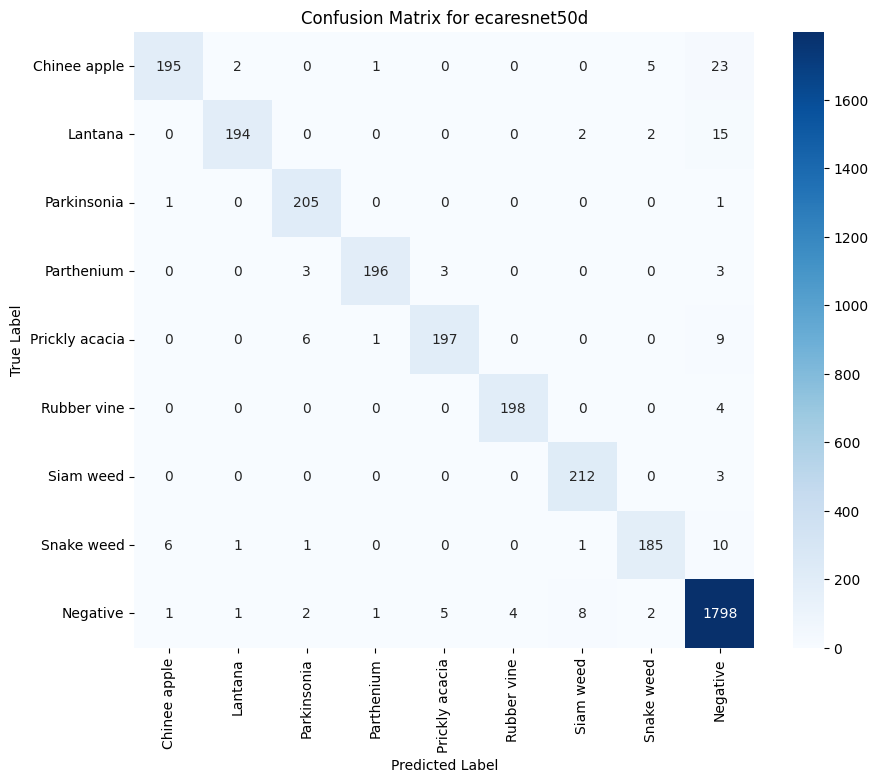

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import timm
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Configuration ---
# --- MODIFIED: Set the model name and path for resnet50d ---
# --- 1. Configuration ---
# --- MODIFIED: Set the correct model name and path ---
MODEL_NAME = 'ecaresnet50d'
# This path points to the file saved in the current session's working directory
FINETUNED_MODEL_PATH = '/kaggle/working/finetuned_ecaresnet50d_fold0.pth' 

IMAGES_DIR = '/kaggle/input/dataset-kiu/images'
LABEL_DIR = '/kaggle/input/dataset-kiu/labels'
TEST_CSV = os.path.join(LABEL_DIR, 'test_subset0.csv')
MASTER_CSV = os.path.join(LABEL_DIR, 'labels.csv')

# --- Parameters ---
BATCH_SIZE = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. Custom Dataset Class ---
class LabeledWeedDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.labels_df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
    def __len__(self):
        return len(self.labels_df)
    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.labels_df.iloc[idx]['Filename'])
        label = self.labels_df.iloc[idx]['Label']
        image = Image.open(img_name).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# --- 3. Load Data and Model ---
test_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

master_df = pd.read_csv(MASTER_CSV)
NUM_CLASSES = len(master_df['Label'].unique())
idx_to_class = {row['Label']: row['Species'] for index, row in master_df.drop_duplicates().iterrows()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class)]

test_dataset = LabeledWeedDataset(csv_file=TEST_CSV, root_dir=IMAGES_DIR, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- MODIFIED: Initialize the correct model architecture ---
print(f"Loading fine-tuned model: {MODEL_NAME}")
model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(FINETUNED_MODEL_PATH))
model.eval()

# --- 4. Make Predictions ---
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- 5. Calculate and Print Metrics ---
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"\nOverall Test Set Accuracy for {MODEL_NAME}: {test_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for {MODEL_NAME}')
plt.show()

Loading fine-tuned model: ecaresnet50d


Testing: 100%|██████████| 110/110 [00:07<00:00, 14.11it/s]



--- Standard Evaluation Metrics ---
Overall Test Set Accuracy for ecaresnet50d: 96.38%

--- ROC Curve Analysis ---


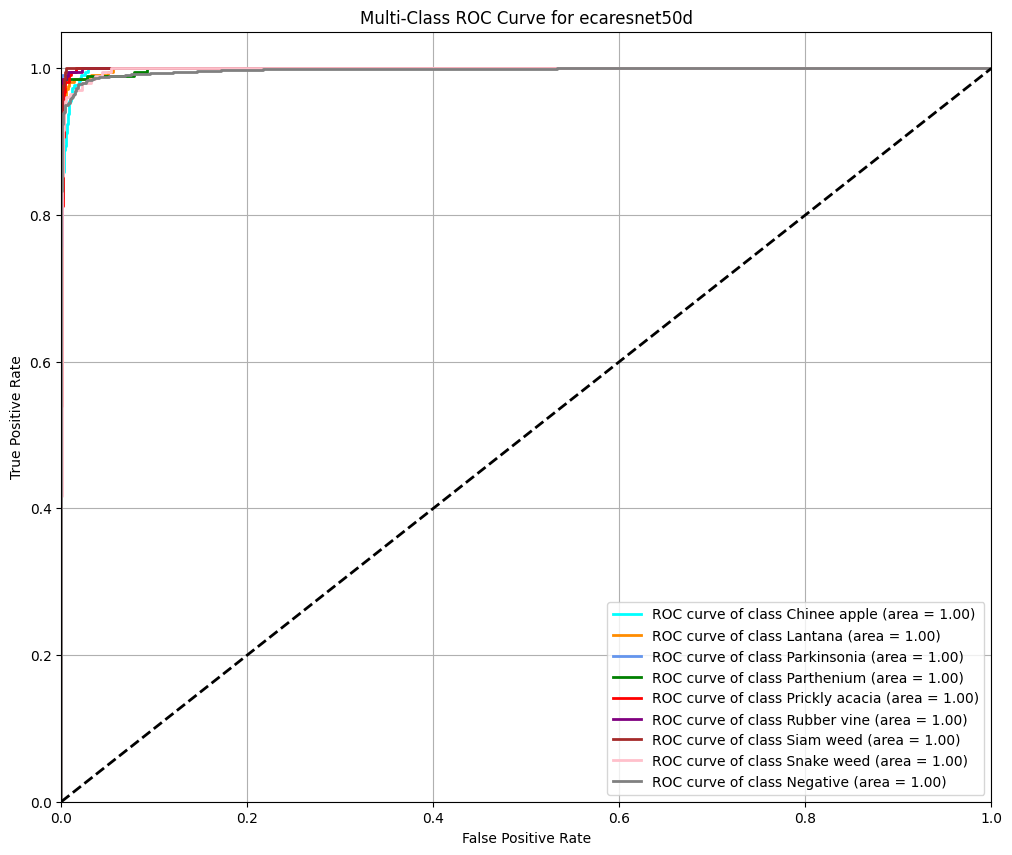

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F  # <-- ADDED THIS IMPORT
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import timm
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize  # <-- ADDED THIS IMPORT
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import cycle  # <-- ADDED THIS IMPORT

# --- 1. Configuration ---
MODEL_NAME = 'ecaresnet50d'  # e.g., 'resnest50d'
FINETUNED_MODEL_PATH = '/kaggle/working/finetuned_ecaresnet50d_fold0.pth'

IMAGES_DIR = '/kaggle/input/dataset-kiu/images'
LABEL_DIR = '/kaggle/input/dataset-kiu/labels'
TEST_CSV = os.path.join(LABEL_DIR, 'test_subset0.csv')
MASTER_CSV = os.path.join(LABEL_DIR, 'labels.csv')

# --- Parameters ---
BATCH_SIZE = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# --- 2. Custom Dataset Class ---
class LabeledWeedDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.labels_df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.labels_df.iloc[idx]['Filename'])
        label = self.labels_df.iloc[idx]['Label']
        image = Image.open(img_name).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


# --- 3. Load Data and Model ---
test_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

master_df = pd.read_csv(MASTER_CSV)
NUM_CLASSES = len(master_df['Label'].unique())
idx_to_class = {row['Label']: row['Species'] for index, row in master_df.drop_duplicates().iterrows()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class)]

test_dataset = LabeledWeedDataset(csv_file=TEST_CSV, root_dir=IMAGES_DIR, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Loading fine-tuned model: {MODEL_NAME}")
model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(FINETUNED_MODEL_PATH))
model.eval()


# --- 4. Make Predictions (MODIFIED TO GET PROBABILITIES) ---
all_preds = []
all_labels = []
all_probs = []  # <-- NEW: Store probabilities for ROC curve

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        # Get class predictions
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Get class probabilities using softmax
        probs = F.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())


# --- 5. Calculate and Print Standard Metrics ---
# (This section with accuracy, classification report, and confusion matrix is the same as before)
print("\n--- Standard Evaluation Metrics ---")
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Overall Test Set Accuracy for {MODEL_NAME}: {test_accuracy * 100:.2f}%")
# ... (your existing code for classification report and confusion matrix plot) ...


# --- 6. NEW: Calculate and Plot ROC Curve ---
print("\n--- ROC Curve Analysis ---")
# Binarize the labels for the One-vs-Rest (OvR) approach
y_true_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
y_probs = np.array(all_probs)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves on one graph
plt.figure(figsize=(12, 10))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown', 'pink', 'gray'])
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Plot the "no-skill" line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Multi-Class ROC Curve for {MODEL_NAME}')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import timm
import pandas as pd
from tqdm import tqdm

# --- 1. Configuration ---
# --- IMPORTANT: Just change the MODEL_NAME for each experiment ---
MODEL_NAME = 'resnest50d' # <-- CHANGE THIS LINE FOR EACH MODEL

# --- CHOOSE FROM YOUR LIST ---
# 'resnest50d'
# 'efficientnet_b3'
# 'resnext50_32x4d'
# 'inception_v3'
# 'convnext_base'
# 'efficientnetv2_m'

IMAGES_DIR = '/kaggle/input/dataset-kiu/images'
LABEL_DIR = '/kaggle/input/dataset-kiu/labels'

# --- Parameters ---
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. Custom Dataset Class Definition ---
class LabeledWeedDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.labels_df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
    def __len__(self):
        return len(self.labels_df)
    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.labels_df.iloc[idx]['Filename'])
        label = self.labels_df.iloc[idx]['Label']
        image = Image.open(img_name).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# --- NEW: EarlyStopping Helper Class ---
class EarlyStopping:
    """Stops training when validation accuracy has stopped improving."""
    def __init__(self, patience=5, min_delta=0.01):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_accuracy = 0
        self.stop_training = False

    def __call__(self, val_accuracy):
        if val_accuracy > self.best_accuracy + self.min_delta:
            self.best_accuracy = val_accuracy
            self.counter = 0
        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                print("Early stopping triggered!")
                self.stop_training = True

# --- 3. Data Transforms and Loading ---
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

MASTER_CSV = os.path.join(LABEL_DIR, 'labels.csv')
master_df = pd.read_csv(MASTER_CSV)
NUM_CLASSES = len(master_df['Label'].unique())
print(f"Total number of classes: {NUM_CLASSES}")

TRAIN_CSV = os.path.join(LABEL_DIR, 'train_subset0.csv')
VAL_CSV = os.path.join(LABEL_DIR, 'val_subset0.csv')
train_dataset = LabeledWeedDataset(csv_file=TRAIN_CSV, root_dir=IMAGES_DIR, transform=train_transform)
val_dataset = LabeledWeedDataset(csv_file=VAL_CSV, root_dir=IMAGES_DIR, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Fold 0: Found {len(train_dataset)} training images and {len(val_dataset)} validation images.")

# --- 4. Model Setup ---
print(f"Loading model: {MODEL_NAME}")
model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
).to(device)

# --- 5. Loss, Optimizer, and Training Loop (MODIFIED) ---
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler()

# Initialize the early stopper
early_stopper = EarlyStopping(patience=5, min_delta=0.01)

print(f"Starting fine-tuning for {MODEL_NAME}...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()

    print(f"Epoch {epoch+1} Train Loss: {running_loss / len(train_loader):.4f}")
    scheduler.step()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Validation Epoch {epoch+1}/{EPOCHS}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Epoch {epoch+1} Validation Accuracy: {accuracy:.2f}%')

    # Call the early stopper
    early_stopper(accuracy)
    
    # Check if we should stop
    if early_stopper.stop_training:
        break

# --- 6. Save the Final Classifier ---
save_path = f'/kaggle/working/finetuned_{MODEL_NAME}_fold0.pth'
torch.save(model.state_dict(), save_path)
print(f"Finished training for {MODEL_NAME}. Final model saved to {save_path}")

Total number of classes: 9
Fold 0: Found 10501 training images and 3501 validation images.
Loading model: resnest50d


/tmp/ipykernel_36/2192685613.py:107: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Starting fine-tuning for resnest50d...


Train Epoch 1/50:   0%|          | 0/329 [00:00<?, ?it/s]/tmp/ipykernel_36/2192685613.py:119: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Train Epoch 1/50: 100%|██████████| 329/329 [01:28<00:00,  3.73it/s]


Epoch 1 Train Loss: 0.8139


...

Epoch 44 Validation Accuracy: 97.94%
EarlyStopping counter: 4 out of 5


Train Epoch 45/50: 100%|██████████| 329/329 [01:28<00:00,  3.73it/s]


Epoch 45 Train Loss: 0.0481


Validation Epoch 45/50: 100%|██████████| 110/110 [00:14<00:00,  7.68it/s]


Epoch 45 Validation Accuracy: 98.03%
EarlyStopping counter: 5 out of 5
Early stopping triggered!
Finished training for resnest50d. Final model saved to /kaggle/working/finetuned_resnest50d_fold0.pth


Loading fine-tuned model: resnest50d


Testing: 100%|██████████| 110/110 [00:14<00:00,  7.64it/s]



Overall Test Set Accuracy for resnest50d: 98.23%

Classification Report:
                precision    recall  f1-score   support

  Chinee apple       0.98      0.93      0.95       226
       Lantana       0.95      0.99      0.97       213
   Parkinsonia       0.99      1.00      0.99       207
    Parthenium       0.98      0.99      0.99       205
Prickly acacia       0.97      0.97      0.97       213
   Rubber vine       0.99      0.99      0.99       202
     Siam weed       0.98      0.99      0.98       215
    Snake weed       0.96      0.96      0.96       204
      Negative       0.99      0.99      0.99      1822

      accuracy                           0.98      3507
     macro avg       0.98      0.98      0.98      3507
  weighted avg       0.98      0.98      0.98      3507


Confusion Matrix:


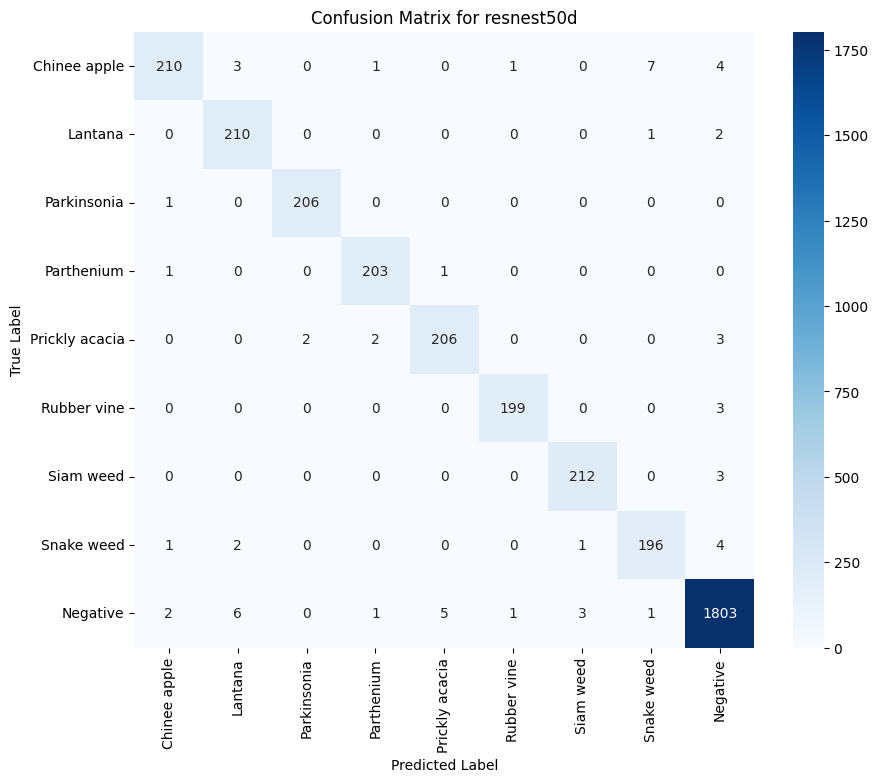

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import timm
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Configuration ---
# --- MODIFIED: Set the model name and path for resnet50d ---
# --- 1. Configuration ---
# --- MODIFIED: Set the correct model name and path ---
MODEL_NAME = 'resnest50d'
# This path points to the file saved in the current session's working directory
FINETUNED_MODEL_PATH = '/kaggle/working/finetuned_resnest50d_fold0.pth' 

IMAGES_DIR = '/kaggle/input/dataset-kiu/images'
LABEL_DIR = '/kaggle/input/dataset-kiu/labels'
TEST_CSV = os.path.join(LABEL_DIR, 'test_subset0.csv')
MASTER_CSV = os.path.join(LABEL_DIR, 'labels.csv')

# --- Parameters ---
BATCH_SIZE = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. Custom Dataset Class ---
class LabeledWeedDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.labels_df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
    def __len__(self):
        return len(self.labels_df)
    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.labels_df.iloc[idx]['Filename'])
        label = self.labels_df.iloc[idx]['Label']
        image = Image.open(img_name).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# --- 3. Load Data and Model ---
test_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

master_df = pd.read_csv(MASTER_CSV)
NUM_CLASSES = len(master_df['Label'].unique())
idx_to_class = {row['Label']: row['Species'] for index, row in master_df.drop_duplicates().iterrows()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class)]

test_dataset = LabeledWeedDataset(csv_file=TEST_CSV, root_dir=IMAGES_DIR, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- MODIFIED: Initialize the correct model architecture ---
print(f"Loading fine-tuned model: {MODEL_NAME}")
model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(FINETUNED_MODEL_PATH))
model.eval()

# --- 4. Make Predictions ---
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- 5. Calculate and Print Metrics ---
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"\nOverall Test Set Accuracy for {MODEL_NAME}: {test_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for {MODEL_NAME}')
plt.show()

Testing: 100%|██████████| 110/110 [00:14<00:00,  7.67it/s]


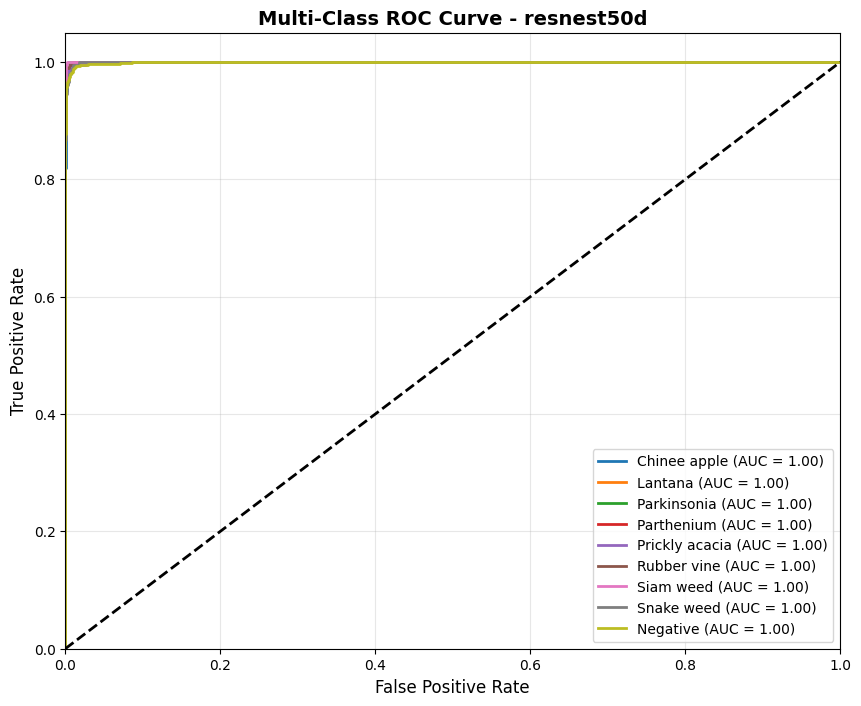

In [10]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# --- 4. Make Predictions (with probabilities for ROC) ---
all_preds = []
all_labels = []
all_probs = []  # store softmax probabilities

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)  # get probabilities

        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())  # keep full probability vectors

# --- 5. ROC Curve for Multi-Class ---
all_labels_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
all_probs = np.array(all_probs)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'{class_name} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'Multi-Class ROC Curve - {MODEL_NAME}', fontsize=14, weight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import timm
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import cycle

# --- 1. Configuration ---
MODEL_NAME = 'resnest50d'
FINETUNED_MODEL_PATH = '/kaggle/working/finetuned_resnest50d_fold0.pth'

IMAGES_DIR = '/kaggle/input/dataset-kiu/images'
LABEL_DIR = '/kaggle/input/dataset-kiu/labels'
TEST_CSV = os.path.join(LABEL_DIR, 'test_subset0.csv')
MASTER_CSV = os.path.join(LABEL_DIR, 'labels.csv')

# --- Parameters ---
BATCH_SIZE = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. Custom Dataset Class ---
class LabeledWeedDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.labels_df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
    def __len__(self):
        return len(self.labels_df)
    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.labels_df.iloc[idx]['Filename'])
        label = self.labels_df.iloc[idx]['Label']
        image = Image.open(img_name).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# --- 3. Load Data and Model ---
test_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
master_df = pd.read_csv(MASTER_CSV)
NUM_CLASSES = len(master_df['Label'].unique())
idx_to_class = {row['Label']: row['Species'] for index, row in master_df.drop_duplicates().iterrows()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class)]
test_dataset = LabeledWeedDataset(csv_file=TEST_CSV, root_dir=IMAGES_DIR, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Loading fine-tuned model: {MODEL_NAME}")
model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(FINETUNED_MODEL_PATH, map_location=device))
model.eval()

# --- 4. Make Predictions ---
all_labels = []
all_probs = []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# --- 5. ROC Curve Calculation ---
y_true_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
y_probs = np.array(all_probs)
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- 6. Plot the "Zoomed-In" ROC Curve ---
plt.figure(figsize=(12, 10))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown', 'pink', 'gray'])
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)

# --- KEY CHANGE: Adjust the axis limits to zoom in ---
plt.xlim([-0.01, 0.1])   # Focus on the 0% to 10% False Positive Rate
plt.ylim([0.85, 1.01])  # Focus on the 85% to 100% True Positive Rate

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'Multi-Class ROC Curve for {MODEL_NAME} (Zoomed-In)', fontsize=14, weight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# --- 0. Installation (Run this cell once) ---
!pip install grad-cam -q

# --- 1. Imports ---
import torch
from torchvision import transforms
from PIL import Image
import timm
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import os

# --- 2. Configuration ---
MODEL_NAME = 'resnest50d'
FINETUNED_MODEL_PATH = '/kaggle/working/finetuned_resnest50d_fold0.pth'
# --- CORRECTED: Define a separate base directory for the images to visualize ---
IMAGES_VIS_DIR = '/kaggle/input/imageeee/imageeee'
LABEL_DIR = '/kaggle/input/dataset-kiu/labels'
MASTER_CSV = os.path.join(LABEL_DIR, 'labels.csv')
NUM_CLASSES = 9
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- CORRECTED: List of just the filenames ---
image_filenames_to_visualize = [
    'Class-Chinee apple.jpg',
    'Class-Lantana.jpg',
    'Class-Negative.jpg',
    'Class-Parkinsonia.jpg',
    'Class-Parthenium.jpg',
    'Class-Prickly acacia.jpg',
    'Class-Rubber vine.jpg',
    'Species-Siam weed.jpg',
    'Species-Snake weed.jpg',
]

# --- 3. Load Model and Class Names ---
print(f"Loading fine-tuned model: {MODEL_NAME}")
model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(FINETUNED_MODEL_PATH, map_location=device))
model.eval()

master_df = pd.read_csv(MASTER_CSV)
idx_to_class = {row['Label']: row['Species'] for index, row in master_df.drop_duplicates().iterrows()}

# --- 4. Identify the Target Layer for ResNeSt ---
# This layer is a good choice as it's the final convolutional block.
# NOTE: This will need to be changed if you use a different architecture (like a ViT).
target_layer = model.layer4[-1]

# --- 5. Main Loop to Generate Visualizations ---
for filename in image_filenames_to_visualize:
    img_path = os.path.join(IMAGES_VIS_DIR, filename)
    
    if not os.path.exists(img_path):
        print(f"Warning: Image not found at {img_path}. Skipping.")
        continue
        
    # --- Extract the true class name from the filename for plotting ---
    true_class_name = filename.split('-')[1].split('.')[0]
    print(f"--- Generating Grad-CAM for: {filename} ---")
    
    # a. Prepare the image
    image = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = transform(image).unsqueeze(0).to(device)

    # b. Set up and run Grad-CAM
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)
    grayscale_cam = grayscale_cam[0, :]

    # c. Create the visualization
    rgb_img = cv2.imread(img_path, 1)[:, :, ::-1]
    rgb_img = cv2.resize(rgb_img, (224, 224))
    rgb_img_float = np.float32(rgb_img) / 255
    visualization = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True)

    # d. Get the predicted class name
    pred_class_idx = model(input_tensor).argmax(axis=1).item()
    pred_class_name = idx_to_class.get(pred_class_idx, "Unknown")

    # e. Plot side-by-side with improved titles
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    
    axs[0].imshow(rgb_img)
    axs[0].set_title(f'Original Image (True: {true_class_name})')
    axs[0].axis('off')

    axs[1].imshow(visualization)
    axs[1].set_title(f'Grad-CAM (Prediction: {pred_class_name})')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# --- 0. Installation (Run this cell once) ---
!pip install grad-cam -q

# --- 1. Imports ---
import torch
from torchvision import transforms
from PIL import Image
import timm
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import os

# --- 2. Configuration (MODIFIED) ---
MODEL_NAME = 'ecaresnet50d'
FINETUNED_MODEL_PATH = '/kaggle/working/finetuned_ecaresnet50d_fold0.pth'
IMAGES_VIS_DIR = '/kaggle/input/imageeee/imageeee'
LABEL_DIR = '/kaggle/input/dataset-kiu/labels'
MASTER_CSV = os.path.join(LABEL_DIR, 'labels.csv')
NUM_CLASSES = 9
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

image_filenames_to_visualize = [
    'Class-Chinee apple.jpg',
    'Class-Lantana.jpg',
    'Class-Negative.jpg',
    'Class-Parkinsonia.jpg',
    'Class-Parthenium.jpg',
    'Class-Prickly acacia.jpg',
    'Class-Rubber vine.jpg',
    'Species-Siam weed.jpg',
    'Species-Snake weed.jpg',
]

# --- 3. Load Model and Class Names ---
print(f"Loading fine-tuned model: {MODEL_NAME}")
model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(FINETUNED_MODEL_PATH, map_location=device))
model.eval()

master_df = pd.read_csv(MASTER_CSV)
idx_to_class = {row['Label']: row['Species'] for index, row in master_df.drop_duplicates().iterrows()}

# --- 4. Identify the Target Layer ---
# This layer works perfectly for ecaresnet50d as well
target_layer = model.layer4[-1]

# --- 5. Main Loop to Generate Visualizations ---
for filename in image_filenames_to_visualize:
    img_path = os.path.join(IMAGES_VIS_DIR, filename)
    
    if not os.path.exists(img_path):
        print(f"Warning: Image not found at {img_path}. Skipping.")
        continue
        
    true_class_name = filename.split('-')[1].split('.')[0]
    print(f"--- Generating Grad-CAM for: {filename} ---")
    
    # a. Prepare the image
    image = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = transform(image).unsqueeze(0).to(device)

    # b. Set up and run Grad-CAM
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)
    grayscale_cam = grayscale_cam[0, :]

    # c. Create the visualization
    rgb_img = cv2.imread(img_path, 1)[:, :, ::-1]
    rgb_img = cv2.resize(rgb_img, (224, 224))
    rgb_img_float = np.float32(rgb_img) / 255
    visualization = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True)

    # d. Get the predicted class name
    pred_class_idx = model(input_tensor).argmax(axis=1).item()
    pred_class_name = idx_to_class.get(pred_class_idx, "Unknown")

    # e. Plot side-by-side
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    
    axs[0].imshow(rgb_img)
    axs[0].set_title(f'Original Image (True: {true_class_name})')
    axs[0].axis('off')

    axs[1].imshow(visualization)
    axs[1].set_title(f'Grad-CAM (Prediction: {pred_class_name})')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()